# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [21]:
# importar librerías
import pandas as pd

In [22]:
# cargar archivo
from pathlib import Path
input_path = Path('data/landing_experiment.csv')
if not input_path.exists():
    input_path = Path('/datasets/landing_experiment.csv')
df = pd.read_csv(input_path)

**Vista previa e información general del conjunto de datos**

In [23]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [24]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**: Haz doble clic en este bloque y escribe qué ves
- Si hay errores como valores nulos o columna con tipo de dato incorrecto, define pasos a seguir. Por ejemplo:
    - Se observan X valores nulos en la columnna ...
    - La columna ... es de tipo de dato ... y debería de ser ... .
- Si no hay errores señalalo y continúa con el proceso. Por ejemplo:
    - El dataset no tiene valores ausentes.
    
 Comienza a escribir debajo de este texto, una vez escritas tus conclusiones, **elimina estas instrucciones** (de aqui hacia arriba de este bloque) para dejar solamente tus hallazgos.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [25]:
print("Número de filas:", len(df))
print("Usuarios únicos:", df["user_id"].nunique())
print("Duplicados:", df.duplicated(subset="user_id").sum())

Número de filas: 40000
Usuarios únicos: 40000
Duplicados: 0


 **Variable `date`**  
Explorar rango de fechas

In [26]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [27]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [35]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [36]:
# Resumen estadístico de usuarios que se convirtieron
df[df["converted"] == 1]["gasto"].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [37]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")

for columna in [
    "landing",
    "region",
    "dispositivo",
    "traffic_source",
    "user_type",
    "converted"
]:
    print(f"\n{columna}")
    print(df[columna].value_counts())


Conteo de categorías:

landing
B    20018
A    19982
Name: landing, dtype: int64

region
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

dispositivo
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

traffic_source
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

user_type
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64

converted
0    34294
1     5706
Name: converted, dtype: int64


Se cargó correctamente el dataset con 40.000 registros y 9 columnas. No se observan valores ausentes, ya que todas las columnas contienen 40.000
valores no nulos. Las variables numéricas (converted y gasto) tienen el tipo de dato correcto. Las variables categóricas también presentan un 
formato adecuado, aunque la columna date se encuentra como tipo object, lo que no representa un problema para este proyecto, ya que únicamente
se utilizará para verificar el rango temporal del experimento.

El análisis exploratorio muestra que el dataset presenta una buena calidad para el análisis estadístico. Cada usuario aparece una única vez 
(40.000 usuarios únicos y ningún duplicado), por lo que la unidad de análisis es consistente. El experimento se desarrolló entre el 01/01/2026
y el 28/01/2026, cubriendo un período continuo de 28 días. La variable gasto presenta muchos valores iguales a cero, lo cual es esperado porque
únicamente los usuarios convertidos realizan compras. Al analizar únicamente los usuarios que convirtieron, se observa un gasto promedio cercano
a 65,37 unidades monetarias. Finalmente, todas las variables categóricas contienen únicamente las categorías esperadas, sin valores inesperados
ni errores de codificación, por lo que el conjunto de datos está listo para continuar con el análisis del experimento A/B.
    

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [40]:
# Gasto por versión
gasto_A = df[(df["landing"] == "A") & (df["converted"] == 1)]["gasto"]

gasto_B = df[(df["landing"] == "B") & (df["converted"] == 1)]["gasto"]

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una diferencia estadísticamente significativa en el gasto promedio de los usuarios que realizaron una compra entre la página A y la página B. 
- **Hipótesis alternativa (H₁):** Existe una diferencia estadísticamente significativa en el gasto promedio de los usuarios que realizaron una compra entre la página A y la página B.

In [42]:
from scipy import stats

# Aplicar prueba
stat, p_value = stats.ttest_ind(
    gasto_A,
    gasto_B,
    equal_var=False
)

# Visualizar resultados
print(f"Estadístico : {stat:.4f}")
print(f"Valor p: {p_value:.4f}")


Estadístico : -9.4810
Valor p: 0.0000


In [43]:
print("Media gasto A:", gasto_A.mean())
print("Media gasto B:", gasto_B.mean())

Media gasto A: 61.0865724522293
Media gasto B: 68.74536005009392


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula, ya que el valor p (0.0000) es menor que el nivel de significancia de 0.05. Existe evidencia estadística de que el gasto promedio de los usuarios que realizaron una compra es diferente entre la página A y la página B.

**Interpretación de negocio:**  
Los resultados muestran que existe una diferencia estadísticamente significativa en el gasto promedio de los usuarios que realizaron una compra. Además, la página B presenta un gasto promedio superior al de la página A (68.75 € frente a 61.09 €), lo que indica que la versión B genera un mayor valor económico por cliente convertido.



## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

---

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una asociación estadísticamente significativa entre la versión de la página (A o B) y la conversión de los usuarios.
- **Hipótesis alternativa (H₁):** Existe una asociación estadísticamente significativa entre la versión de la página (A o B) y la conversión de los usuarios

In [44]:
# Número de usuarios convertidos por página
convertidos = df.groupby("landing")["converted"].sum()

# Total de usuarios por página
totales = df.groupby("landing")["converted"].count()

print("Usuarios convertidos por página:\n", convertidos)
print("\nTotal de usuarios por página:\n", totales)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [45]:
from scipy.stats import chi2_contingency

# Construir tabla de contingencia
tabla = pd.crosstab(df["landing"], df["converted"])

# Aplicar prueba Chi-cuadrado
chi2, p_value, dof, expected = chi2_contingency(tabla)

# Visualizar resultados
print(f"Estadístico : {chi2:.4f}")
print(f"Valor p: {p_value:.4f}")

Estadístico : 93.3748
Valor p: 0.0000


In [46]:
tasa_conversion = (
    df.groupby("landing")["converted"]
      .mean()
      .mul(100)
)

print(tasa_conversion)

landing
A    12.571314
B    15.955640
Name: converted, dtype: float64


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula, ya que el valor p (0.0000) es menor que el nivel de significancia de 0.05. Existe evidencia estadística de que la versión de la página está asociada con la conversión de los usuarios.

**Interpretación de negocio:**  
Los resultados indican que la página B obtiene una tasa de conversión superior a la página A (15.96 % frente a 12.57 %). La diferencia es estadísticamente significativa, por lo que la versión B demuestra ser más efectiva para convertir visitantes en clientes. Desde una perspectiva de negocio, implementar la página B podría aumentar el número de conversiones y mejorar el rendimiento de la estrategia comercial.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba 

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una asociación estadísticamente significativa entre la fuente de tráfico (traffic_source) y la conversión (converted).
- **Hipótesis alternativa (H₁):** Existe una asociación estadísticamente significativa entre la fuente de tráfico (traffic_source) y la conversión (converted).

In [47]:
# Construir tabla de contingencia
tabla_trafico = pd.crosstab(df["traffic_source"], df["converted"])

tabla_trafico

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


In [48]:
from scipy.stats import chi2_contingency

# Aplicar prueba Chi-cuadrado
chi2, p_value, dof, expected = chi2_contingency(tabla_trafico)

# Visualizar resultados
print(f"Estadístico : {chi2:.4f}")
print(f"Valor p: {p_value:.4f}")

Estadístico : 8.6621
Valor p: 0.0341


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula (H₀), ya que el valor p (0.0341) es menor que el nivel de significancia de 0.05. Existe evidencia estadísticamente significativa de que la fuente de tráfico está asociada con la conversión de los usuarios.

**Interpretación de negocio:**  
Los resultados indican que la probabilidad de conversión varía según la fuente de tráfico. Esto significa que algunos canales de adquisición generan mejores resultados que otros, por lo que la empresa debería identificar cuáles presentan las mayores tasas de conversión para optimizar la inversión en marketing y dirigir más recursos hacia los canales más efectivos.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una asociación estadísticamente significativa entre el tipo de usuario (user_type) y la conversión (converted).
- **Hipótesis alternativa (H₁):** Existe una asociación estadísticamente significativa entre el tipo de usuario (user_type) y la conversión (converted).

In [49]:
# Construir tabla de contingencia
tabla_usuario = pd.crosstab(df["user_type"], df["converted"])

tabla_usuario

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [50]:
from scipy.stats import chi2_contingency

In [51]:
# Aplicar prueba
chi2, p_value, dof, expected = chi2_contingency(tabla_usuario)

# Visualizar resultados
print(f"Estadístico : {chi2:.4f}")
print(f"Valor p: {p_value:.4f}")


Estadístico : 0.5135
Valor p: 0.4736


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula (H₀), ya que el valor p (0.4736) es mayor que el nivel de significancia de 0.05. No existe evidencia estadísticamente significativa de una asociación entre el tipo de usuario (nuevo o recurrente) y la conversión.

**Interpretación de negocio:**  
Los resultados indican que el tipo de usuario (nuevo o recurrente) no influye de forma significativa en la probabilidad de conversión. Esto sugiere que ambos grupos presentan un comportamiento de conversión similar, por lo que no sería recomendable diseñar estrategias diferentes basadas únicamente en esta variable.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

In [52]:
import matplotlib.pyplot as plt

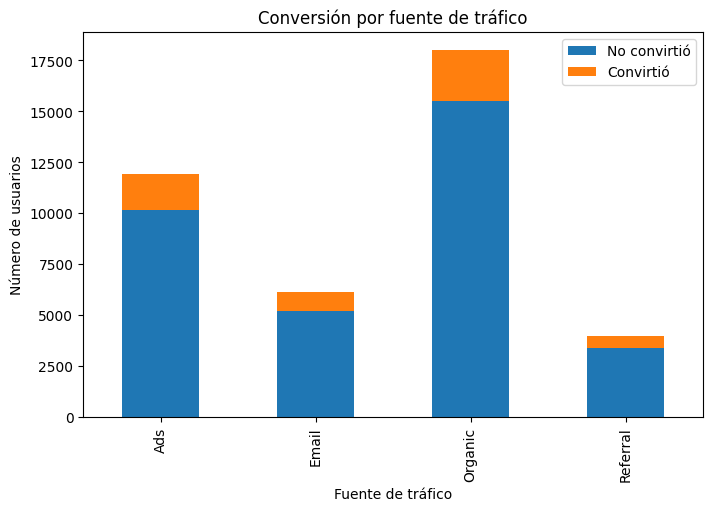

In [53]:
# Tabla de contingencia
tabla_trafico = pd.crosstab(df["traffic_source"], df["converted"])

# Gráfico de barras apiladas
tabla_trafico.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Conversión por fuente de tráfico")
plt.xlabel("Fuente de tráfico")
plt.ylabel("Número de usuarios")
plt.legend(["No convirtió", "Convirtió"])
plt.show()

✍️ **Comentario**: El gráfico muestra la cantidad de usuarios que convirtieron y no convirtieron según la fuente de tráfico. Organic concentra el mayor volumen de usuarios, seguido por Ads, mientras que Email y Referral presentan menores cantidades. Además, se observan diferencias en la distribución de conversiones entre los canales, lo que coincide con la prueba Chi-cuadrado realizada anteriormente, indicando que existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión.

### Relación entre el tipo de usuario y la conversión

In [54]:
tabla_usuario = pd.crosstab(df["user_type"], df["converted"])
tabla_usuario

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


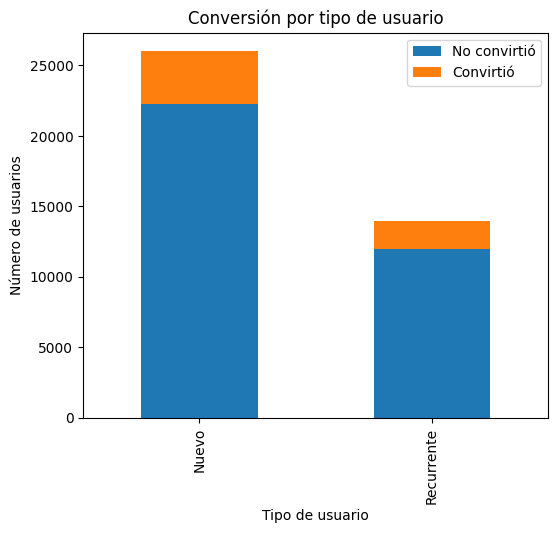

In [55]:
import matplotlib.pyplot as plt

tabla_usuario.plot(
    kind="bar",
    stacked=True,
    figsize=(6,5)
)

plt.title("Conversión por tipo de usuario")
plt.xlabel("Tipo de usuario")
plt.ylabel("Número de usuarios")
plt.legend(["No convirtió", "Convirtió"])
plt.show()

✍️ **Comentario**: El gráfico muestra la cantidad de usuarios que convirtieron y no convirtieron según el tipo de usuario. Los usuarios nuevos representan un mayor volumen total que los recurrentes; sin embargo, la proporción de conversiones es visualmente similar en ambos grupos. Este resultado coincide con la prueba Chi-cuadrado realizada anteriormente, cuyo valor p fue de 0.4736, indicando que no existe una asociación estadísticamente significativa entre el tipo de usuario y la conversión.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- La página B obtuvo un gasto promedio por usuario convertido mayor (68.75) que la página A (61.09).
- La prueba t de Welch mostró un valor p = 0.0000, indicando que la diferencia observada es estadísticamente significativa.
- **Interpretación:**
  La versión B no solo convierte usuarios, sino que también genera un mayor ingreso promedio por compra. Esto sugiere que implementar la página B puede incrementar el valor económico generado por cada cliente.
<br>

**Tasa de conversión:** 
- La tasa de conversión de la página B fue de 15.96 %, mientras que la página A alcanzó 12.57 %.
- La prueba Chi-cuadrado obtuvo un valor p = 0.0000, por lo que existe evidencia estadística de diferencias entre ambas páginas.
- **Interpretación:**
   La página B logra convertir una mayor proporción de visitantes en clientes, por lo que representa una mejor alternativa para incrementar las conversiones del negocio.
---

#### 📊 **Segmentación por fuente de tráfico**
- La prueba Chi-cuadrado indicó una asociación significativa entre la fuente de tráfico y la conversión (p = 0.0341). Los distintos canales presentan comportamientos de conversión diferentes.
- **Interpretación:**
  La efectividad de conversión depende del canal de adquisición. Conviene analizar con mayor detalle qué fuentes generan mejores resultados para optimizar la inversión en marketing.
 ---

#### 📊 **Segmentación por tipo de usuario**
- La prueba Chi-cuadrado obtuvo un valor p = 0.4736, por lo que no se encontraron diferencias significativas entre usuarios nuevos y recurrentes respecto a la conversión.
- **Interpretación:**
   En este experimento, el tipo de usuario no parece influir en la probabilidad de conversión. No existe evidencia suficiente para justificar estrategias diferenciadas entre ambos grupos.
---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
- Implementar la versión B como página principal, ya que obtuvo una mayor tasa de conversión y un mayor gasto promedio por usuario convertido.
- Analizar con mayor profundidad el desempeño de cada fuente de tráfico para concentrar la inversión de marketing en los canales con mayor potencial de conversión.